# Labor Market Data — Exploration

Quick sanity checks and exploratory analysis on the BLS/Census data before building dashboard views.

In [21]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine('sqlite:///../data/labor_market.db')
bls_df = pd.read_sql('SELECT * FROM bls_timeseries', engine, parse_dates=['date'])
census_df = pd.read_sql('SELECT * FROM census_state_snapshot', engine)

bls_df.head()

,series_id,series_name,state_name,state_fips,year,month,value,date
0,CES0500000003,avg_hourly_earnings,NaN,NaN,2016,1,25.37,2016-01-01
1,CES0500000003,avg_hourly_earnings,NaN,NaN,2016,2,25.38,2016-02-01
2,CES0500000003,avg_hourly_earnings,NaN,NaN,2016,3,25.45,2016-03-01
3,CES0500000003,avg_hourly_earnings,NaN,NaN,2016,4,25.53,2016-04-01
4,CES0500000003,avg_hourly_earnings,NaN,NaN,2016,5,25.58,2016-05-01


In [22]:
bls_df['series_name'].value_counts().head(20)

series_name
avg_hourly_earnings                       127
nonfarm_payrolls                          127
unemployment_rate_national                127
unemployment_rate_alabama                 126
unemployment_rate_alaska                  126
unemployment_rate_arizona                 126
unemployment_rate_arkansas                126
unemployment_rate_california              126
unemployment_rate_colorado                126
unemployment_rate_connecticut             126
unemployment_rate_delaware                126
unemployment_rate_district_of_columbia    126
unemployment_rate_florida                 126
unemployment_rate_georgia                 126
unemployment_rate_hawaii                  126
unemployment_rate_idaho                   126
unemployment_rate_illinois                126
unemployment_rate_indiana                 126
unemployment_rate_iowa                    126
unemployment_rate_kansas                  126
Name: count, dtype: int64

<Axes: title={'center': 'National Unemployment Rate'}, xlabel='date'>

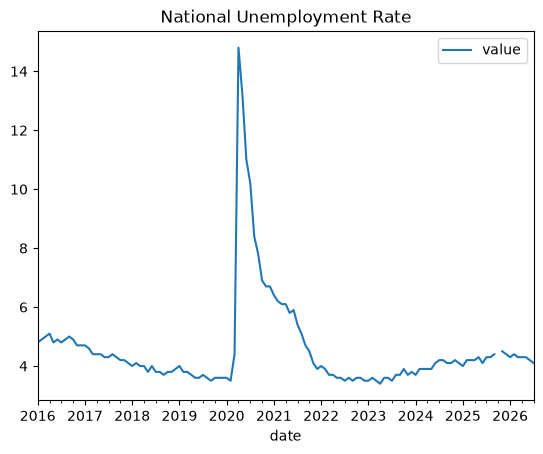

In [23]:
national_unemployment = bls_df[
    bls_df["series_name"] == "unemployment_rate_national"
]
national_unemployment.plot(
    x="date",
    y="value",
    title="National Unemployment Rate",
)

In [24]:
census_df.sort_values('unemployment_rate_pct', ascending=False).head(10)

,state_name,labor_force,unemployed,bachelors_degree,total_population,state_fips,unemployment_rate_pct,bachelors_rate_pct
51,Puerto Rico,1305263,119634,524456,3205691,72,9.17,16.36
4,California,20137422,1110856,6137666,38965193,06,5.52,15.75
8,District of Columbia,406660,21386,129951,678972,11,5.26,19.14
32,New York,10107326,506633,3136170,19571216,36,5.01,16.02
18,Louisiana,2135043,104094,525591,4573749,22,4.88,11.49
1,Alaska,362965,17505,99091,733406,02,4.82,13.51
24,Mississippi,1343059,64637,307215,2939690,28,4.81,10.45
31,New Mexico,995436,47766,257431,2114371,35,4.80,12.18
39,Rhode Island,587754,28012,182054,1095962,44,4.77,16.61
30,New Jersey,5023152,237647,1712683,9290841,34,4.73,18.43
